In [2]:
# importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries are imported sucessfully")

All libraries are imported sucessfully


In [3]:
# Loading and exploring the dataset
df = pd.read_csv(r'C:\Users\dtoot\ChurnPredection\data\raw\WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(df.shape) # to see the dimensions of the dataset
print(df.describe(include = 'all'))


(7043, 21)
        customerID gender  SeniorCitizen Partner Dependents       tenure  \
count         7043   7043    7043.000000    7043       7043  7043.000000   
unique        7043      2            NaN       2          2          NaN   
top     7590-VHVEG   Male            NaN      No         No          NaN   
freq             1   3555            NaN    3641       4933          NaN   
mean           NaN    NaN       0.162147     NaN        NaN    32.371149   
std            NaN    NaN       0.368612     NaN        NaN    24.559481   
min            NaN    NaN       0.000000     NaN        NaN     0.000000   
25%            NaN    NaN       0.000000     NaN        NaN     9.000000   
50%            NaN    NaN       0.000000     NaN        NaN    29.000000   
75%            NaN    NaN       0.000000     NaN        NaN    55.000000   
max            NaN    NaN       1.000000     NaN        NaN    72.000000   

       PhoneService MultipleLines InternetService OnlineSecurity  ...  \
cou

In [4]:
print(df.head(7))

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   
5  9305-CDSKC  Female              0      No         No       8          Yes   
6  1452-KIOVK    Male              0      No        Yes      22          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...

In [5]:
# Binary Encoding
# Binary Categorical columns (2 unique values)
binary_cols = [
    'gender' , 'Partner' , 'Dependents' , "PhoneService" , "PaperlessBilling" , 'Churn'
]

df[binary_cols] = df[binary_cols].replace({
    'Yes' : 1 , "No" : 0,
    "Male" : 1 , "Female" : 0
})


C:\Users\dtoot\AppData\Local\Temp\ipykernel_14416\467228352.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[binary_cols] = df[binary_cols].replace({


In [6]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,0,0,1,0,1,0,No phone service,DSL,No,...,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0
1,5575-GNVDE,1,0,0,0,34,1,No,DSL,Yes,...,Yes,No,No,No,One year,0,Mailed check,56.95,1889.5,0
2,3668-QPYBK,1,0,0,0,2,1,No,DSL,Yes,...,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1
3,7795-CFOCW,1,0,0,0,45,0,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,0,0,0,0,2,1,No,Fiber optic,No,...,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1


In [7]:
#One-Hot-encoding
# Categorical columns with > 2 unique values
multi_cat_cols = [
    'MultipleLines' , 'InternetService' , 'OnlineSecurity' , 'OnlineBackup' , 'DeviceProtection',
    'TechSupport' , 'StreamingTV' , "StreamingMovies" , 'Contract' , "PaymentMethod"
]

df = pd.get_dummies(df , columns = multi_cat_cols , drop_first = True)

In [8]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,0,0,1,0,1,0,1,29.85,29.85,...,False,False,False,False,False,False,False,False,True,False
1,5575-GNVDE,1,0,0,0,34,1,0,56.95,1889.5,...,False,False,False,False,False,True,False,False,False,True
2,3668-QPYBK,1,0,0,0,2,1,1,53.85,108.15,...,False,False,False,False,False,False,False,False,False,True
3,7795-CFOCW,1,0,0,0,45,0,0,42.30,1840.75,...,True,False,False,False,False,True,False,False,False,False
4,9237-HQITU,0,0,0,0,2,1,1,70.70,151.65,...,False,False,False,False,False,False,False,False,True,False


In [9]:
# cleaning

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'] , errors = 'coerce')

In [10]:
df = df.drop('customerID' , axis = 1)

In [11]:
bool_cols = df.select_dtypes(include = 'bool').columns
df[bool_cols] = df[bool_cols].astype(int)


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7043 non-null   int64  
 1   SeniorCitizen                          7043 non-null   int64  
 2   Partner                                7043 non-null   int64  
 3   Dependents                             7043 non-null   int64  
 4   tenure                                 7043 non-null   int64  
 5   PhoneService                           7043 non-null   int64  
 6   PaperlessBilling                       7043 non-null   int64  
 7   MonthlyCharges                         7043 non-null   float64
 8   TotalCharges                           7032 non-null   float64
 9   Churn                                  7043 non-null   int64  
 10  MultipleLines_No phone service         7043 non-null   int64  
 11  Mult

In [13]:
#finding the correlation
corr_matrix = df.corr(numeric_only = True)
# focus on the corr for churn
churn_corr = corr_matrix[['Churn']].sort_values(by = 'Churn' , ascending = False) # we used sort_values to make it descending
print(churn_corr)

                                          Churn
Churn                                  1.000000
InternetService_Fiber optic            0.308020
PaymentMethod_Electronic check         0.301919
MonthlyCharges                         0.193356
PaperlessBilling                       0.191825
SeniorCitizen                          0.150889
StreamingTV_Yes                        0.063228
StreamingMovies_Yes                    0.061382
MultipleLines_Yes                      0.040102
PhoneService                           0.011942
gender                                -0.008612
MultipleLines_No phone service        -0.011942
DeviceProtection_Yes                  -0.066160
OnlineBackup_Yes                      -0.082255
PaymentMethod_Mailed check            -0.091683
PaymentMethod_Credit card (automatic) -0.134302
Partner                               -0.150448
Dependents                            -0.164221
TechSupport_Yes                       -0.164674
OnlineSecurity_Yes                    -0

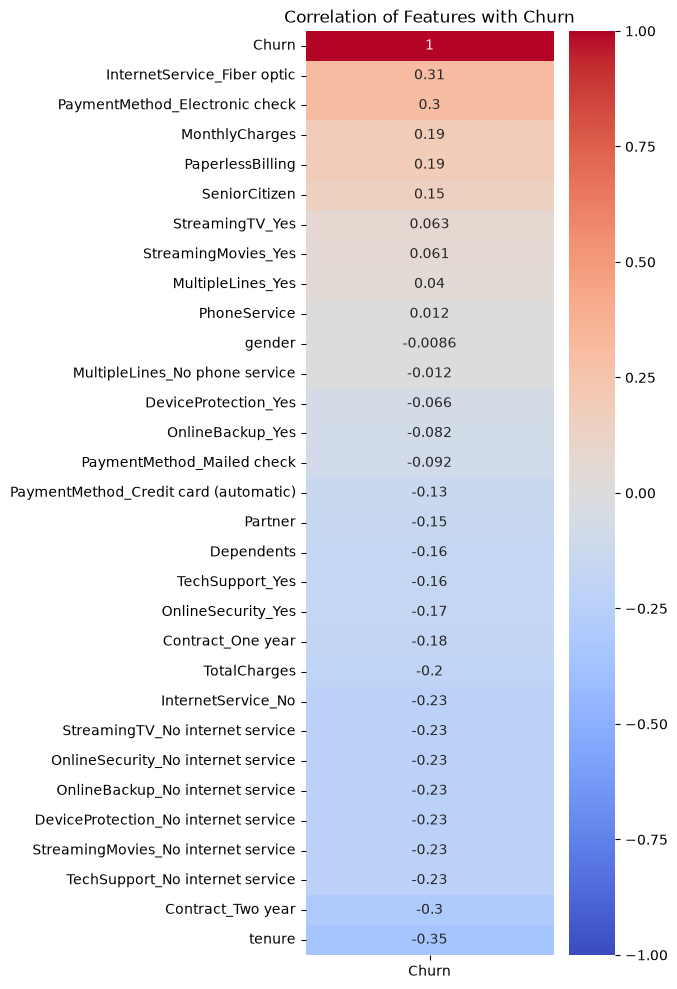

In [14]:
# plotting the heatmap of the corr

plt.figure(figsize = (4,12))
sns.heatmap(churn_corr , annot = True , cmap = 'coolwarm' , vmin = -1 , vmax = 1)
plt.title('Correlation of Features with Churn')
plt.show()

In [15]:
# machine learning
# we have a class imbalance (27% churners and 73% staying)
df['Churn'].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report , precision_score, recall_score, f1_score
import pandas as pd
import time



X = df.drop(columns = ['Churn'])
y = df['Churn']


X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.2 , random_state = 4 , stratify = y)
threshold = 0.3

models = {
    "Random Forest Classifier" : RandomForestClassifier(n_estimators = 300 , class_weight = "balanced" , random_state = 42 , n_jobs = -1),
    "LightGBM" : LGBMClassifier(n_estimators=500,learning_rate=0.05,class_weight='balanced',random_state=42,n_jobs=-1),
    "XGBoost" : XGBClassifier(n_estimators = 500 , learning_rate = 0.05 , max_depth = 6 , subsample = 0.8 , colsample_bytree = 0.8 , random_state = 42 , n_jobs = -1 , scale_pos_weight = (y_train ==0).sum() / (y_train ==1).sum() , eval_metric = 'logloss')
}

for name , model in models.items():
    if name in ["LightGBM", "XGBoost"]:
        # training timer
        start_train = time.time()
        model.fit(X_train , y_train)
        train_time = time.time() - start_train
        print(f"Training time : {train_time:.2f} seconds")

        # prediction timer
        start_pred = time.time()
        proba = model.predict_proba(X_test)[: , 1]
        y_pred = (proba >= threshold).astype(int)
        pred_time = time.time() - start_pred
        print(f"Prediction time : {pred_time:.2f} seconds")

        #Classification Report
        print(classification_report(y_test , y_pred , digits = 3))
        print()
        print(f"Threshold tuning for {model}")
        for thresh in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
         preds = (proba >= thresh).astype(int)
         prec = precision_score(y_test, preds, pos_label=1)
         rec = recall_score(y_test, preds, pos_label=1)
         f1 = f1_score(y_test, preds, pos_label=1)
         print(f"{thresh:<8}{prec:<8.3f}{rec:<8.3f}{f1:<8.3f}")
        continue

    model.fit(X_train , y_train)
    proba = model.predict_proba(X_test)[: , 1]
    y_pred = (proba >= threshold).astype(int)
    print(classification_report(y_test , y_pred , digits = 3))
    print()
    print(f"Threshold tuning for {model}")
    for thresh in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
     preds = (proba >= thresh).astype(int)
     prec = precision_score(y_test, preds, pos_label=1)
     rec = recall_score(y_test, preds, pos_label=1)
     f1 = f1_score(y_test, preds, pos_label=1)
     print(f"{thresh:<8}{prec:<8.3f}{rec:<8.3f}{f1:<8.3f}")


              precision    recall  f1-score   support

           0      0.917     0.640     0.754      1035
           1      0.457     0.840     0.592       374

    accuracy                          0.693      1409
   macro avg      0.687     0.740     0.673      1409
weighted avg      0.795     0.693     0.711      1409


Threshold tuning for RandomForestClassifier(class_weight='balanced', n_estimators=300, n_jobs=-1,
                       random_state=42)
0.25    0.429   0.882   0.577   
0.3     0.457   0.840   0.592   
0.35    0.480   0.781   0.595   
0.4     0.504   0.730   0.596   
0.45    0.522   0.684   0.593   
0.5     0.537   0.636   0.583   
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000567 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enou

In [17]:
import optuna
from xgboost import XGBClassifier
from sklearn.metrics import recall_score
from sklearn.model_selection import train_test_split

def objective(trial):
    params = {
        "n_estimators" : trial.suggest_int("n_estimators" , 300 , 800),
        "learning_rate" : trial.suggest_float("learning_rate" , 0.01 , 0.2),
        "max_depth" : trial.suggest_int("max_depth" , 3 , 10),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 5),
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 5),
        "random_state": 42,
        "n_jobs": -1,
        "scale_pos_weight": (y_train == 0).sum() / (y_train == 1).sum(),
        "eval_metric": "logloss"
    }

    model = XGBClassifier(**params)
    model.fit(X_train , y_train)
    proba = model.predict_proba(X_test)[: , 1]
    y_pred = (proba >= threshold).astype(int)
    return recall_score(y_test , y_pred , pos_label = 1)

#run optuna
study = optuna.create_study(direction = "maximize")
study.optimize(objective , n_trials = 100)

print("Best Params:" , study.best_params)
print("Best Recall:" , study.best_value)

[I 2026-09-22 19:13:54,000] A new study created in memory with name: no-name-737d185f-c0a7-4244-b6ea-3611f342b063
[I 2026-09-22 19:13:54,177] Trial 0 finished with value: 0.8716577540106952 and parameters: {'n_estimators': 359, 'learning_rate': 0.15915414605240602, 'max_depth': 8, 'subsample': 0.5415205164870848, 'colsample_bytree': 0.7052402492145375, 'min_child_weight': 1, 'gamma': 2.769334260344945, 'reg_alpha': 3.528479529093869, 'reg_lambda': 4.023844185439774}. Best is trial 0 with value: 0.8716577540106952.
[I 2026-09-22 19:13:54,334] Trial 1 finished with value: 0.8529411764705882 and parameters: {'n_estimators': 471, 'learning_rate': 0.1943818544430709, 'max_depth': 9, 'subsample': 0.7748393676447245, 'colsample_bytree': 0.939008494418207, 'min_child_weight': 5, 'gamma': 2.734406218916062, 'reg_alpha': 0.6254108024315896, 'reg_lambda': 3.2514736699374946}. Best is trial 0 with value: 0.8716577540106952.
[I 2026-09-22 19:13:54,552] Trial 2 finished with value: 0.858288770053475

Best Params: {'n_estimators': 374, 'learning_rate': 0.010940788623388554, 'max_depth': 3, 'subsample': 0.6736677004860183, 'colsample_bytree': 0.6002200248426455, 'min_child_weight': 9, 'gamma': 1.6654025537629416, 'reg_alpha': 0.5790846523644257, 'reg_lambda': 1.805122492266155}
Best Recall: 0.9224598930481284


In [18]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
import time

# Calculate scale_pos_weight for imbalance
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# Add the scale_pos_weight and fixed params to the best ones from Optuna
best_params = study.best_params
best_params.update({
    "random_state": 42,
    "n_jobs": -1,
    "scale_pos_weight": scale_pos_weight,
    "eval_metric": "logloss"
})

# Create model from best params
xgb = XGBClassifier(**best_params)

# Training timer
start_train = time.time()
xgb.fit(X_train, y_train)
train_time = time.time() - start_train
print(f"⏱ Training time: {train_time:.2f} seconds")

# Prediction timer
start_pred = time.time()
proba = xgb.predict_proba(X_test)[:, 1]
y_pred = (proba >= threshold).astype(int)
pred_time = time.time() - start_pred
print(f"⏱ Prediction time: {pred_time:.4f} seconds")

# Classification report
print(classification_report(y_test, y_pred, digits=3))

⏱ Training time: 0.14 seconds
⏱ Prediction time: 0.0040 seconds
              precision    recall  f1-score   support

           0      0.952     0.551     0.698      1035
           1      0.426     0.922     0.583       374

    accuracy                          0.649      1409
   macro avg      0.689     0.737     0.640      1409
weighted avg      0.812     0.649     0.667      1409



In [19]:
import mlflow
import mlflow.xgboost

from sklearn.metrics import (
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

import time
import os


# ============================================================
# MLflow Tracking Configuration
# ============================================================

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))

mlflow_db = os.path.join(project_root, "mlflow.db")

mlflow.set_tracking_uri(f"sqlite:///{mlflow_db}")

mlflow.set_experiment("Telco Churn - XGBoost")


# ============================================================
# Start MLflow Run
# ============================================================

with mlflow.start_run():

    # --------------------------------------------------------
    # Calculate class imbalance weight
    # --------------------------------------------------------

    scale_pos_weight = (
        (y_train == 0).sum() /
        (y_train == 1).sum()
    )

    # --------------------------------------------------------
    # Best parameters from Optuna
    # --------------------------------------------------------

    best_params = study.best_params.copy()

    best_params.update({
        "random_state": 42,
        "n_jobs": -1,
        "scale_pos_weight": scale_pos_weight,
        "eval_metric": "logloss"
    })

    # --------------------------------------------------------
    # Log parameters
    # --------------------------------------------------------

    mlflow.log_params(best_params)

    mlflow.log_param("threshold", threshold)

    # --------------------------------------------------------
    # Train model
    # --------------------------------------------------------

    start_train = time.time()

    xgb = XGBClassifier(**best_params)

    xgb.fit(X_train, y_train)

    train_time = time.time() - start_train

    mlflow.log_metric("train_time", train_time)

    # --------------------------------------------------------
    # Prediction
    # --------------------------------------------------------

    start_pred = time.time()

    proba = xgb.predict_proba(X_test)[:, 1]

    y_pred = (proba >= threshold).astype(int)

    pred_time = time.time() - start_pred

    mlflow.log_metric("pred_time", pred_time)

    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------

    precision = precision_score(
        y_test,
        y_pred,
        pos_label=1
    )

    recall = recall_score(
        y_test,
        y_pred,
        pos_label=1
    )

    f1 = f1_score(
        y_test,
        y_pred,
        pos_label=1
    )

    auc = roc_auc_score(
        y_test,
        proba
    )

    # --------------------------------------------------------
    # Log metrics
    # --------------------------------------------------------

    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1", f1)
    mlflow.log_metric("roc_auc", auc)

    # --------------------------------------------------------
    # Log model
    # --------------------------------------------------------

    mlflow.xgboost.log_model(
        xgb,
        "model"
    )

    # --------------------------------------------------------
    # Print results
    # --------------------------------------------------------

    print(classification_report(
        y_test,
        y_pred,
        digits=3
    ))

2026/09/22 19:14:12 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


              precision    recall  f1-score   support

           0      0.952     0.551     0.698      1035
           1      0.426     0.922     0.583       374

    accuracy                          0.649      1409
   macro avg      0.689     0.737     0.640      1409
weighted avg      0.812     0.649     0.667      1409

